In [11]:
# compute_pca.py
import os
import numpy as np
from PIL import Image
import torch
from sklearn.decomposition import PCA, IncrementalPCA
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "dataset/train"
IMG_SIZE = (150, 150)  # matches assignment
CLASSES = sorted([d.name for d in Path(DATA_DIR).iterdir() if d.is_dir()])

In [12]:
def load_images(max_per_class=None):
    print('Inside load images function ***')
    X, y, paths = [], [], []
    for cls_idx, cls in enumerate(CLASSES):
        cls_dir = Path(DATA_DIR) / cls
        files = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png"))
        if max_per_class:
            files = files[:max_per_class]
        for p in files:
            img = Image.open(p).convert("RGB").resize(IMG_SIZE)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            X.append(arr.ravel())
            y.append(cls_idx)
            paths.append(str(p))
    print('Returning from load images function ***')
    return np.stack(X), np.array(y), paths

In [13]:
print('Loading the images ***')
X, y, paths = load_images()
print(X.shape)
print(y.shape)
print(len(paths))

Loading the images ***
Inside load images function ***
Returning from load images function ***
(12402, 67500)
(12402,)
12402


In [14]:
# mean-center(standardization of data)
X_mean = X.mean(axis=0)
Xc = X - X_mean

In [6]:
# PCA for visualization
print('Perform PCA **')
pca = PCA(n_components=2, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Xc)
print("Explained variance (2 PCs):", pca.explained_variance_ratio_.sum())

Perform PCA **
Explained variance (2 PCs): 0.36897284


In [ ]:
print("Explained variance by component:", pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

Explained variance by component: [0.23781121 0.13116165]
Total variance captured: 0.36897284


Plotting PCA scatter plot for PCA on 2 axes ***


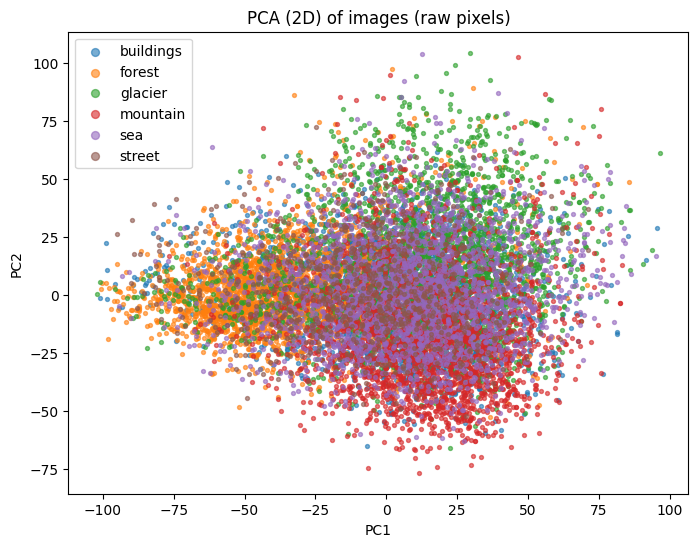

In [8]:
print('Plotting PCA scatter plot for PCA on 2 axes ***')
# scatter
plt.figure(figsize=(8,6))
for cls_idx, cls in enumerate(CLASSES):
    mask = y==cls_idx
    plt.scatter(Z[mask,0], Z[mask,1], s=8, label=cls, alpha=0.6)
plt.legend(markerscale=2)
plt.title("PCA (2D) of images (raw pixels)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

In [9]:
# PCA on 3 axes
print('Perform PCA **')
pca = PCA(n_components=3, svd_solver="randomized", random_state=0)
Z = pca.fit_transform(Xc)
print("Explained variance (3 PCs):", pca.explained_variance_ratio_.sum())

Perform PCA **
Explained variance (3 PCs): 0.42807546


In [10]:
print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance captured in 3 components:", sum(pca.explained_variance_ratio_))

Explained variance by each component: [0.23781121 0.13116173 0.05910252]
Total variance captured in 3 components: 0.42807546


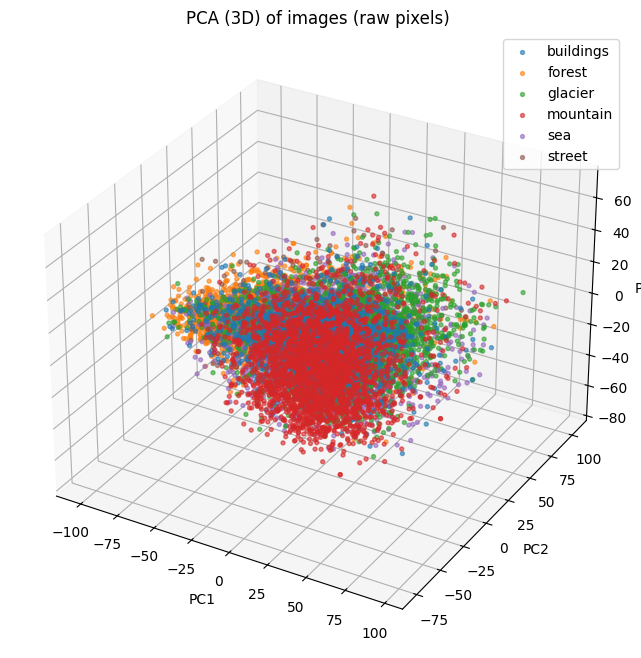

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for cls_idx, cls in enumerate(CLASSES):
    mask = y == cls_idx
    ax.scatter(Z[mask,0], Z[mask,1], Z[mask,2], s=8, label=cls, alpha=0.6)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA (3D) of images (raw pixels)')
ax.legend()
plt.show()

In [15]:
print('Identifying outliers based on PCA projection ***')

# Show top outliers by projection distance from class centroid
outlier_scores = []
for cls_idx in range(len(CLASSES)):
    mask = (y==cls_idx)
    centroid = Z[mask].mean(axis=0)
    dists = np.linalg.norm(Z[mask] - centroid, axis=1)
    # store global mapping
    idxs = np.where(mask)[0]
    for i, dist in zip(idxs, dists):
        outlier_scores.append((dist, i))
outlier_scores.sort(reverse=True)
top = outlier_scores[:50]
print(f'Top outlier scores: {top}')

Identifying outliers based on PCA projection ***


NameError: name 'Z' is not defined

In [ ]:
# Save CSV for review
import csv
print('Writing results to analysis/pca_outliers.csv ***')
with open("analysis/pca_outliers.csv","w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["score","index","path","label"])
    for score,i in top:
        writer.writerow([score, i, paths[i], CLASSES[y[i]]])
print("Wrote analysis/pca_outliers.csv (top suspicious samples)")

In [16]:
#GPU check

print(f"Is MPS available? {torch.backends.mps.is_available()}")
print(f"Is MPS built? {torch.backends.mps.is_built()}")

Is MPS available? True
Is MPS built? True


In [17]:
ideal_workers = os.cpu_count()
print(ideal_workers)

8


In [18]:
#Baseline model
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        
        # Conv Block 1: Conv -> ReLU -> MaxPool
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv Block 2: Conv -> ReLU -> MaxPool
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv Block 3: Conv -> ReLU -> MaxPool
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate flattened size after conv layers
        # Input: 150x150 -> after pool1: 75x75 -> after pool2: 37x37 -> after pool3: 18x18
        self.flattened_size = 128 * 18 * 18
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Conv Block 1
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Conv Block 2
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Conv Block 3
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

# Initialize model with number of classes
num_classes = len(CLASSES)
model = CNN(num_classes)

# Print model architecture
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=41472, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=6, bias=True)
)


In [19]:
# Create dataset loader for training
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

class OutdoorSceneDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.images = []
        self.labels = []
        
        for cls_idx, cls in enumerate(CLASSES):
            cls_dir = self.data_dir / cls
            if cls_dir.exists():
                for img_path in cls_dir.glob("*.jpg"):
                    self.images.append(str(img_path))
                    self.labels.append(cls_idx)
                for img_path in cls_dir.glob("*.png"):
                    self.images.append(str(img_path))
                    self.labels.append(cls_idx)
        
        print(f"Loaded {len(self.images)} images from {len(CLASSES)} classes")
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset and dataloader
train_dataset = OutdoorSceneDataset(DATA_DIR, transform=train_transform)

# Use num_workers=0 to avoid multiprocessing issues on macOS with Jupyter notebooks
# num_workers > 0 causes pickling errors with dataset classes defined in notebooks
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# Training setup - Use MPS for M1 Mac GPU acceleration
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple MPS (Metal Performance Shaders) for GPU acceleration")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("Using CUDA for GPU acceleration")
else:
    device = torch.device('cpu')
    print("Using CPU")

# Move model to device
model = CNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training on {device}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"DataLoader num_workers: 0 (disabled to avoid multiprocessing issues)")

Loaded 12402 images from 6 classes
Using Apple MPS (Metal Performance Shaders) for GPU acceleration
Training on mps
Number of classes: 6
Training samples: 12402
DataLoader num_workers: 0 (disabled to avoid multiprocessing issues)


In [ ]:
# Evaluate model on validation data (unseen during training)
from sklearn.metrics import classification_report

# Create validation dataset
val_data_dir = "dataset/validation_data"
val_dataset = OutdoorSceneDataset(val_data_dir, transform=train_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Validation samples: {len(val_dataset)}")

# Evaluate on validation set
model.eval()
val_correct = 0
val_total = 0
all_val_labels = []
all_val_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        all_val_labels.extend(labels.cpu().numpy())
        all_val_predictions.extend(predicted.cpu().numpy())

val_accuracy = 100 * val_correct / val_total
print(f'\nValidation Accuracy: {val_accuracy:.2f}%')
print(f'Training Accuracy (final epoch): 88.74%')
print(f'Accuracy Gap: {88.74 - val_accuracy:.2f}%')

# Print detailed classification report
print("\nValidation Classification Report:")
print(classification_report(all_val_labels, all_val_predictions, target_names=CLASSES))

In [20]:
# Training loop
num_epochs = 5
model.train()

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    print(f'Epoch [{epoch+1}/{num_epochs}] completed. Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print('Training completed!')

Epoch [1/5], Batch [50/388], Loss: 1.2096
Epoch [1/5], Batch [100/388], Loss: 1.0560
Epoch [1/5], Batch [150/388], Loss: 0.9923
Epoch [1/5], Batch [200/388], Loss: 0.9401
Epoch [1/5], Batch [250/388], Loss: 0.8580
Epoch [1/5], Batch [300/388], Loss: 0.7319
Epoch [1/5], Batch [350/388], Loss: 0.9050
Epoch [1/5] completed. Loss: 1.0411, Accuracy: 62.62%
Epoch [2/5], Batch [50/388], Loss: 0.5706
Epoch [2/5], Batch [100/388], Loss: 0.6061
Epoch [2/5], Batch [150/388], Loss: 0.6858
Epoch [2/5], Batch [200/388], Loss: 0.4495
Epoch [2/5], Batch [250/388], Loss: 0.4145
Epoch [2/5], Batch [300/388], Loss: 0.7881
Epoch [2/5], Batch [350/388], Loss: 0.9393
Epoch [2/5] completed. Loss: 0.7281, Accuracy: 74.69%
Epoch [3/5], Batch [50/388], Loss: 0.3040
Epoch [3/5], Batch [100/388], Loss: 0.8404
Epoch [3/5], Batch [150/388], Loss: 0.5386
Epoch [3/5], Batch [200/388], Loss: 0.4797
Epoch [3/5], Batch [250/388], Loss: 0.4484
Epoch [3/5], Batch [300/388], Loss: 0.7146
Epoch [3/5], Batch [350/388], Loss:

In [21]:
#Testing trained model on validation set
# Evaluate model on validation data (unseen during training)
from sklearn.metrics import classification_report

# Create validation dataset
val_data_dir = "dataset/validation_data"
val_dataset = OutdoorSceneDataset(val_data_dir, transform=train_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Validation samples: {len(val_dataset)}")

# Evaluate on validation set
model.eval()
val_correct = 0
val_total = 0
all_val_labels = []
all_val_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()
        
        all_val_labels.extend(labels.cpu().numpy())
        all_val_predictions.extend(predicted.cpu().numpy())

val_accuracy = 100 * val_correct / val_total
print(f'\nValidation Accuracy: {val_accuracy:.2f}%')
print(f'Training Accuracy (final epoch): 88.74%')
print(f'Accuracy Gap: {88.74 - val_accuracy:.2f}%')

# Print detailed classification report
print("\nValidation Classification Report:")
print(classification_report(all_val_labels, all_val_predictions, target_names=CLASSES))

Loaded 240 images from 6 classes
Validation samples: 240

Validation Accuracy: 81.25%
Training Accuracy (final epoch): 88.74%
Accuracy Gap: 7.49%

Validation Classification Report:
              precision    recall  f1-score   support

   buildings       0.81      0.75      0.78        40
      forest       0.90      0.95      0.93        40
     glacier       0.68      0.90      0.77        40
    mountain       0.87      0.82      0.85        40
         sea       0.85      0.82      0.84        40
      street       0.81      0.62      0.70        40

    accuracy                           0.81       240
   macro avg       0.82      0.81      0.81       240
weighted avg       0.82      0.81      0.81       240



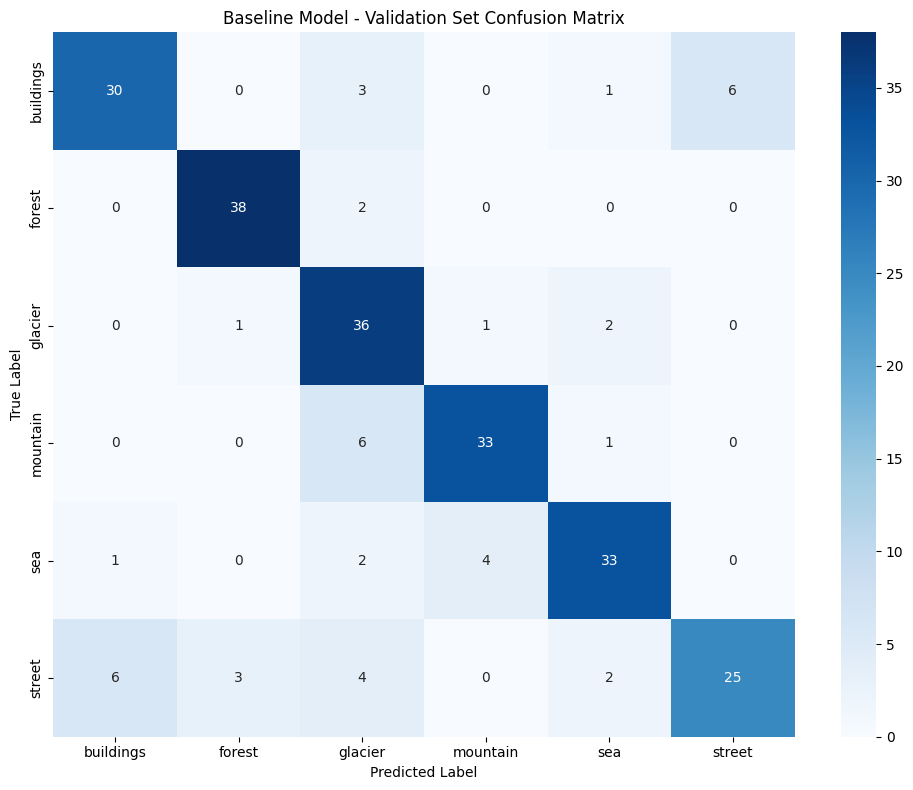

Validation Confusion Matrix saved to evaluation/baseline_validation_confusion_matrix.png


In [23]:
# Generate confusion matrix for validation set
from sklearn.metrics import confusion_matrix

# Create confusion matrix using validation predictions
cm_val = confusion_matrix(all_val_labels, all_val_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model - Validation Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_validation_confusion_matrix.png')
plt.show()

print("Validation Confusion Matrix saved to evaluation/baseline_validation_confusion_matrix.png")

In [ ]:
#Confusion matix and output layer value for training data


Processed batch [50/388]
Processed batch [100/388]
Processed batch [150/388]
Processed batch [200/388]
Processed batch [250/388]
Processed batch [300/388]
Processed batch [350/388]

Loss Statistics:
Median: 0.0310
75th percentile: 0.1120
90th percentile: 0.4523
95th percentile: 1.0510
99th percentile: 2.4261

Total training samples analyzed: 12402
Mislabeled samples (prediction != true): 822
High loss samples (>95th percentile): 621


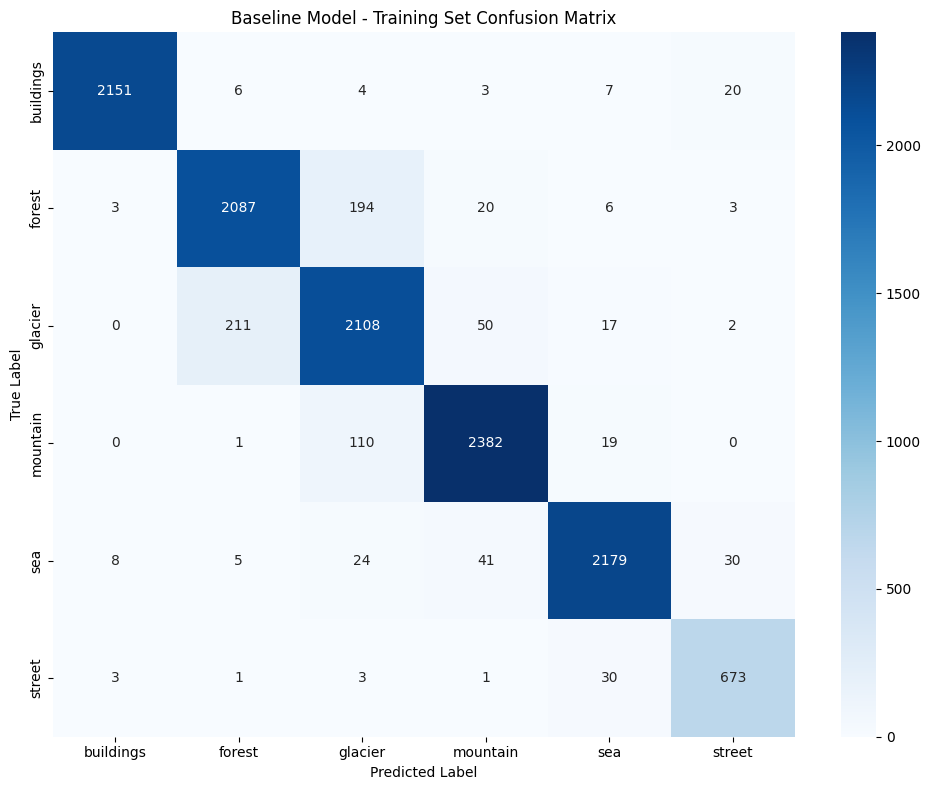

Training Confusion Matrix saved to evaluation/baseline_training_confusion_matrix.png

Training data map created with loss values, logits, and paths for mislabel detection.
Use loss_95th or loss_99th as threshold to identify potentially mislabeled samples.


In [25]:
# Collect raw logits, loss values, and paths for training data analysis
model.eval()
all_train_labels = []
all_train_predictions = []
all_train_logits = []
all_train_paths = []
all_train_losses = []

# Create index to path mapping from dataset
index_to_path = {i: path for i, path in enumerate(train_dataset.images)}

print("Collecting training data with logits, loss values, and paths...")
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass to get raw logits
        logits = model(images)
        
        # Calculate loss for each sample in the batch
        batch_losses = F.cross_entropy(logits, labels, reduction='none')
        
        # Get predictions
        _, predicted = torch.max(logits, 1)
        
        # Store data
        all_train_labels.extend(labels.cpu().numpy())
        all_train_predictions.extend(predicted.cpu().numpy())
        all_train_logits.append(logits.cpu().numpy())
        all_train_losses.extend(batch_losses.cpu().numpy())
        
        # Get paths for this batch
        batch_start_idx = batch_idx * train_loader.batch_size
        batch_end_idx = min(batch_start_idx + len(labels), len(train_dataset))
        batch_paths = [index_to_path[i] for i in range(batch_start_idx, batch_end_idx)]
        all_train_paths.extend(batch_paths)
        
        if (batch_idx + 1) % 50 == 0:
            print(f'Processed batch [{batch_idx+1}/{len(train_loader)}]')

# Concatenate all logits
all_train_logits = np.vstack(all_train_logits)
all_train_losses = np.array(all_train_losses)

# Calculate loss statistics
loss_median = np.median(all_train_losses)
loss_75th = np.percentile(all_train_losses, 75)
loss_90th = np.percentile(all_train_losses, 90)
loss_95th = np.percentile(all_train_losses, 95)
loss_99th = np.percentile(all_train_losses, 99)

print(f"\nLoss Statistics:")
print(f"Median: {loss_median:.4f}")
print(f"75th percentile: {loss_75th:.4f}")
print(f"90th percentile: {loss_90th:.4f}")
print(f"95th percentile: {loss_95th:.4f}")
print(f"99th percentile: {loss_99th:.4f}")

# Create mapping: image_index -> (path, true_label, predicted_label, logits, loss)
training_data_map = {}
for i in range(len(all_train_labels)):
    training_data_map[i] = {
        'path': all_train_paths[i],
        'true_label': all_train_labels[i],
        'predicted_label': all_train_predictions[i],
        'logits': all_train_logits[i],
        'loss': all_train_losses[i],
        'is_mislabeled': all_train_labels[i] != all_train_predictions[i]
    }

print(f"\nTotal training samples analyzed: {len(training_data_map)}")
print(f"Mislabeled samples (prediction != true): {sum(1 for x in training_data_map.values() if x['is_mislabeled'])}")
print(f"High loss samples (>95th percentile): {sum(1 for x in training_data_map.values() if x['loss'] > loss_95th)}")

# Generate confusion matrix for training set
cm_train = confusion_matrix(all_train_labels, all_train_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model - Training Set Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_training_confusion_matrix.png')
plt.show()

print("Training Confusion Matrix saved to evaluation/baseline_training_confusion_matrix.png")
print("\nTraining data map created with loss values, logits, and paths for mislabel detection.")
print("Use loss_95th or loss_99th as threshold to identify potentially mislabeled samples.")

In [ ]:
# Remove mislabeled data - samples with cross-entropy loss in 99th percentile
from torch.utils.data import Subset

# Identify indices of samples to keep (loss < 99th percentile)
indices_to_keep = [i for i, data in training_data_map.items() if data['loss'] < loss_99th]
indices_to_remove = [i for i, data in training_data_map.items() if data['loss'] >= loss_99th]

print(f"Original training samples: {len(train_dataset)}")
print(f"Samples to remove (loss >= 99th percentile): {len(indices_to_remove)}")
print(f"Samples to keep (loss < 99th percentile): {len(indices_to_keep)}")
print(f"Removal rate: {100 * len(indices_to_remove) / len(train_dataset):.2f}%")

# Create filtered dataset using Subset
cleaned_train_dataset = Subset(train_dataset, indices_to_keep)

# Create new DataLoader with cleaned dataset
cleaned_train_loader = DataLoader(cleaned_train_dataset, batch_size=32, shuffle=True, num_workers=0)

print(f"\nCleaned training dataset size: {len(cleaned_train_dataset)}")
print(f"Cleaned DataLoader batches: {len(cleaned_train_loader)}")

In [ ]:
#Remove mislabeled data - all those samples where the cross entropy loss value is in the 99th percentile

In [ ]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained model
torch.save(model.state_dict(), 'models/baseline_model.pth')
print("Model saved as models/baseline_model.pth")

In [ ]:
# Export to ONNX format
model.eval()
dummy_input = torch.randn(1, 3, 150, 150).to(device)

# Export the model
torch.onnx.export(
    model,                          # model being run
    dummy_input,                    # model input (or a tuple for multiple inputs)
    "models/baseline_model.onnx",   # where to save the model
    export_params=True,             # store the trained parameter weights inside the model file
    opset_version=11,               # the ONNX version to export to
    do_constant_folding=True,       # whether to execute constant folding for optimization
    input_names=['input'],          # the model's input names
    output_names=['output'],        # the model's output names
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}  # variable length axes
)

print("Model exported to models/baseline_model.onnx")

In [ ]:
# Generate confusion matrix
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Baseline Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

# Save confusion matrix
os.makedirs('evaluation', exist_ok=True)
plt.savefig('evaluation/baseline_confusion_matrix.png')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=CLASSES))